In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import chess
from stockfish import Stockfish

In [21]:
DB_PATH = "F:/databases/chess.db"
STOCKFISH_PATH = r"C:\Users\maxol\chess\engines\stockfish\stockfish-windows-x86-64-avx2"
stockfish = Stockfish(STOCKFISH_PATH)

cnxn = sqlite3.connect(DB_PATH)
cursor = cnxn.cursor()

In [22]:
search_df = pd.read_sql_query('SELECT * FROM searches', cnxn)
depth_df = pd.read_sql_query('SELECT * FROM searches_by_depth', cnxn)

print(len(search_df), len(depth_df))
display(search_df.head())
display(depth_df.head())

166 95304


,id,game_id,sts_id,fen,ply,time,eval,move,principal_variation,depth,nodes,q_nodes,tt_stores,tt_hits,fail_highs,fail_lows,ingestion_timestamp
0,1,6,None,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,9,105.0,100000,d2d3,None,5,42878,12335,4882,361,8234,842,2026-01-12 23:18:12
1,2,5,None,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N2NP1/PP1PPPB...,10,100.0,-26,d7d6,None,5,63998,17866,9880,1107,13185,1297,2026-01-12 23:18:12
2,3,6,None,r1bqk2r/pp1pppbp/2n2np1/2p5/2P5/2NP2P1/PP2PPBP...,11,103.0,30,c1g5,None,4,27869,10513,3506,158,6563,421,2026-01-12 23:18:12
3,4,5,None,r1bqk1nr/pp2ppbp/2np2p1/2p5/2P5/2N2NP1/PP1PPPB...,12,100.0,-137,g8f6,None,5,63688,26915,7709,832,16451,1079,2026-01-12 23:18:12
4,5,6,None,r1bq1rk1/pp1pppbp/2n2np1/2p3B1/2P5/2NP2P1/PP2P...,13,100.0,8,d1d2,None,4,8611,5751,1299,42,3037,0,2026-01-12 23:18:12


,search_id,depth,time,eval,move,nodes,q_nodes,tt_stores,tt_hits,fail_highs,fail_lows,ingestion_timestamp
0,1,1,0.1608,25,d2d3,125,31,0,0,0,1,2026-01-12 23:18:13
1,1,2,1.3653,34,d2d3,2878,262,3832,0,1932,0,2026-01-12 23:18:13
2,1,3,6.2101,17,e2e3,5493,1400,1017,361,2181,815,2026-01-12 23:18:13
3,1,4,83.2632,30,d2d3,32935,4399,32,0,1920,26,2026-01-12 23:18:13
4,1,5,14.4792,100000,d2d3,1447,3230,1,0,1382,0,2026-01-12 23:18:13


In [23]:
def stockfish_eval(fen, depth=10):
    stockfish.set_fen_position(fen)
    # Get evaluation in centipawns (or mate in x)
    info = stockfish.get_evaluation()  # {'type': 'cp', 'value': 23} or {'type': 'mate', 'value': 3}
    
    if info["type"] == "cp":
        return info["value"]  # convert centipawns to pawns
    else:
        # Convert mate score to a large value for regression purposes
        # positive for winning, negative for losing
        return 1000 if info["value"] > 0 else -1000

In [24]:
full_search_df = pd.read_sql_query(
    """
    SELECT sbd.*, s.fen
    FROM searches_by_depth sbd
    JOIN searches s ON sbd.search_id = s.id
    """,
    cnxn
)

full_search_df['sf_eval'] = full_search_df['fen'].apply(stockfish_eval)
full_search_df['elo_diff'] = full_search_df['eval'] - full_search_df['sf_eval']

display(full_search_df)

,search_id,depth,time,eval,move,nodes,q_nodes,tt_stores,tt_hits,fail_highs,fail_lows,ingestion_timestamp,fen,sf_eval,elo_diff
0,1,1,0.1608,25,d2d3,125,31,0,0,0,1,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,23,2
1,1,2,1.3653,34,d2d3,2878,262,3832,0,1932,0,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,21,13
2,1,3,6.2101,17,e2e3,5493,1400,1017,361,2181,815,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,21,-4
3,1,4,83.2632,30,d2d3,32935,4399,32,0,1920,26,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,29,1
4,1,5,14.4792,100000,d2d3,1447,3230,1,0,1382,0,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,27,99973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95299,166,6540,0.0150,0,g1g5,29,0,0,0,0,0,2026-01-12 23:18:13,8/8/5K2/1k6/8/8/8/6Q1 w - - 75 99,1000,-1000
95300,166,6541,0.0150,0,f6e6,29,0,0,0,0,0,2026-01-12 23:18:13,8/8/5K2/1k6/8/8/8/6Q1 w - - 75 99,1000,-1000
95301,166,6542,0.0150,0,g1h1,29,0,0,0,0,0,2026-01-12 23:18:13,8/8/5K2/1k6/8/8/8/6Q1 w - - 75 99,1000,-1000
95302,166,6543,0.0149,0,g1g5,29,0,0,0,0,0,2026-01-12 23:18:13,8/8/5K2/1k6/8/8/8/6Q1 w - - 75 99,1000,-1000


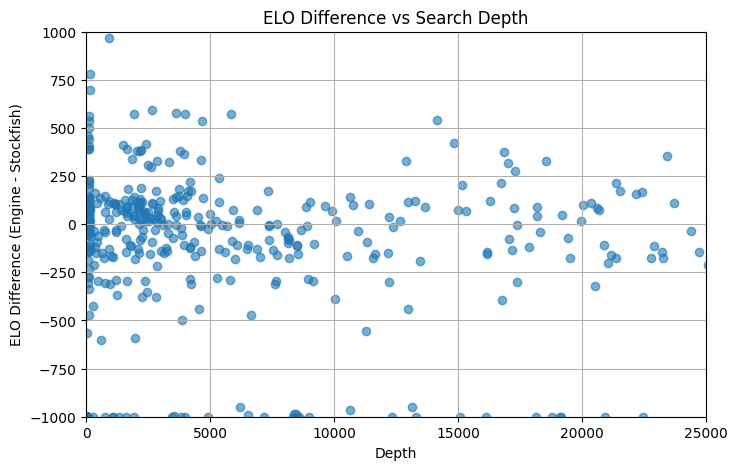

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(full_search_df["nodes"], full_search_df["elo_diff"], alpha=0.6)
plt.ylim(-1000,1000)
plt.xlim(0,25000)
plt.xlabel("Depth")
plt.ylabel("ELO Difference (Engine - Stockfish)")
plt.title("ELO Difference vs Search Depth")
plt.grid(True)
plt.show()
